In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/customer_churn_cleaned.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7021, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Define target variable
target = "Churn"

# Separate features and target
X = df.drop(columns=[target])
y = df[target].map({"No": 0, "Yes": 1})

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print(y.value_counts(normalize=True) * 100)

Features shape: (7021, 19)
Target shape: (7021,)

Target distribution:
Churn
0    5164
1    1857
Name: count, dtype: int64

Target percentage:
Churn
0    73.550776
1    26.449224
Name: proportion, dtype: float64


In [3]:
# Identify numerical and categorical features

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "str"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Number of numerical features: 4
Number of categorical features: 15


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training data: (5616, 19)
Testing data: (1405, 19)

Training target distribution:
Churn
0    4131
1    1485
Name: count, dtype: int64

Testing target distribution:
Churn
0    1033
1     372
Name: count, dtype: int64


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [7]:
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [8]:
preprocessor_unscaled = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

In [11]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_scaled),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

In [12]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_unscaled),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ))
    ]
)

In [13]:
gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_unscaled),
        ("classifier", GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]
)

In [14]:
svm_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_scaled),
        ("classifier", SVC(
            kernel="rbf",
            probability=True,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

In [15]:
print("Training Logistic Regression...")

logistic_model.fit(X_train, y_train)

print("Logistic Regression training completed.")

Training Logistic Regression...
Logistic Regression training completed.


In [16]:
print("Training Random Forest...")

random_forest_model.fit(X_train, y_train)

print("Random Forest training completed.")

Training Random Forest...
Random Forest training completed.


In [17]:
print("Training Gradient Boosting...")

gradient_boosting_model.fit(X_train, y_train)

print("Gradient Boosting training completed.")

Training Gradient Boosting...
Gradient Boosting training completed.


In [18]:
print("Training SVM...")

svm_model.fit(X_train, y_train)

print("SVM training completed.")

Training SVM...


c:\Users\Nethmi\Documents\GitHub\AWS-Customer-Churn-Prediction\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVM training completed.


In [19]:
# Generate predictions for all four models

y_pred_lr = logistic_model.predict(X_test)
y_pred_rf = random_forest_model.predict(X_test)
y_pred_gb = gradient_boosting_model.predict(X_test)
y_pred_svm = svm_model.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


In [20]:
# Generate churn probabilities

y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]
y_prob_gb = gradient_boosting_model.predict_proba(X_test)[:, 1]
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]

print("Probability predictions generated successfully.")

Probability predictions generated successfully.


In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [22]:
results = []

models = {
    "Logistic Regression": (y_pred_lr, y_prob_lr),
    "Random Forest": (y_pred_rf, y_prob_rf),
    "Gradient Boosting": (y_pred_gb, y_prob_gb),
    "SVM": (y_pred_svm, y_prob_svm)
}

for model_name, (y_pred, y_prob) in models.items():

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.741637,0.507881,0.779570,0.615058,0.839781
1,Random Forest,0.760142,0.542998,0.594086,0.567394,0.816300
2,Gradient Boosting,0.798577,0.649832,0.518817,0.576981,0.839630
3,SVM,0.762278,0.535316,0.774194,0.632967,0.824871


In [23]:
results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.741637,0.507881,0.779570,0.615058,0.839781
1,Gradient Boosting,0.798577,0.649832,0.518817,0.576981,0.839630
2,SVM,0.762278,0.535316,0.774194,0.632967,0.824871
3,Random Forest,0.760142,0.542998,0.594086,0.567394,0.816300


In [24]:
print("LOGISTIC REGRESSION")
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["No Churn", "Churn"]
))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1033
       Churn       0.51      0.78      0.62       372

    accuracy                           0.74      1405
   macro avg       0.70      0.75      0.71      1405
weighted avg       0.80      0.74      0.76      1405



In [25]:
print("RANDOM FOREST")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["No Churn", "Churn"]
))

RANDOM FOREST
              precision    recall  f1-score   support

    No Churn       0.85      0.82      0.83      1033
       Churn       0.54      0.59      0.57       372

    accuracy                           0.76      1405
   macro avg       0.70      0.71      0.70      1405
weighted avg       0.77      0.76      0.76      1405



In [26]:
print("GRADIENT BOOSTING")
print(classification_report(
    y_test,
    y_pred_gb,
    target_names=["No Churn", "Churn"]
))

GRADIENT BOOSTING
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1033
       Churn       0.65      0.52      0.58       372

    accuracy                           0.80      1405
   macro avg       0.74      0.71      0.72      1405
weighted avg       0.79      0.80      0.79      1405



In [27]:
print("SVM")
print(classification_report(
    y_test,
    y_pred_svm,
    target_names=["No Churn", "Churn"]
))

SVM
              precision    recall  f1-score   support

    No Churn       0.90      0.76      0.82      1033
       Churn       0.54      0.77      0.63       372

    accuracy                           0.76      1405
   macro avg       0.72      0.77      0.73      1405
weighted avg       0.81      0.76      0.77      1405



In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

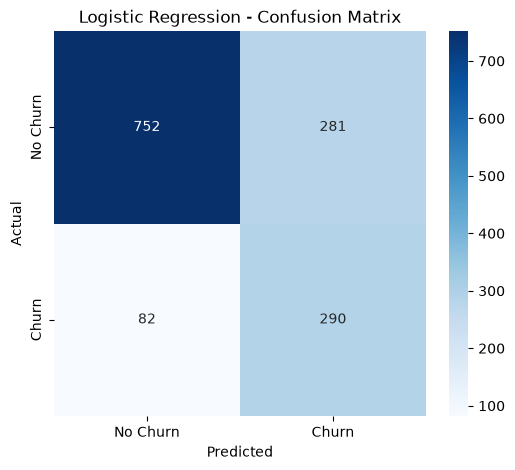

In [29]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

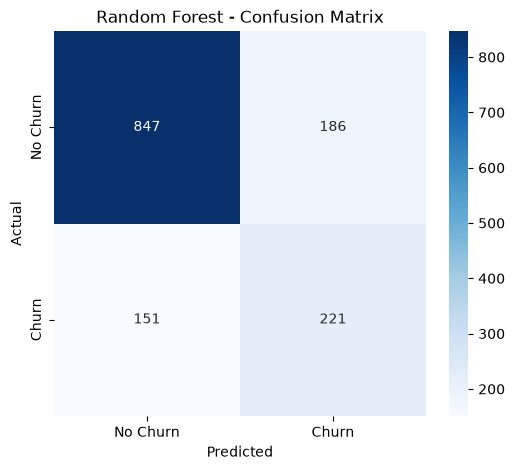

In [30]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

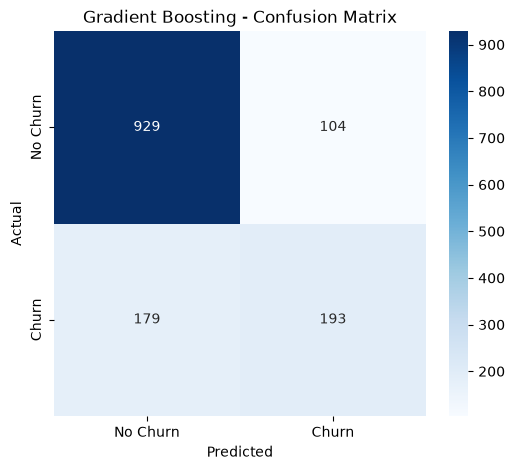

In [31]:
cm_gb = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_gb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Gradient Boosting - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

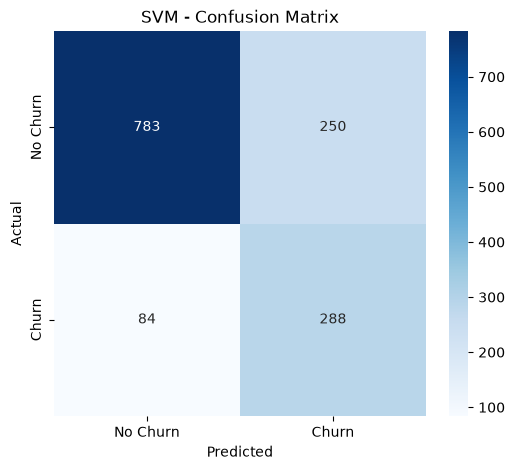

In [32]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("SVM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [33]:
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)

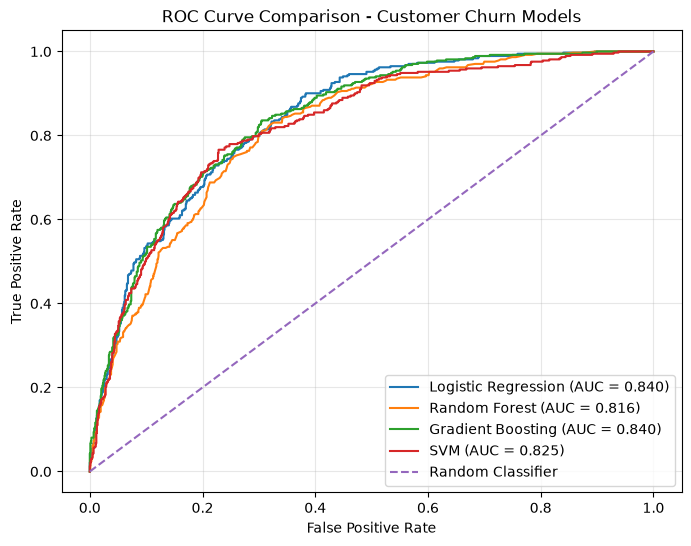

In [34]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})"
)

plt.plot(
    fpr_gb,
    tpr_gb,
    label=f"Gradient Boosting (AUC = {roc_auc_score(y_test, y_prob_gb):.3f})"
)

plt.plot(
    fpr_svm,
    tpr_svm,
    label=f"SVM (AUC = {roc_auc_score(y_test, y_prob_svm):.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - Customer Churn Models")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [35]:
# Get transformed feature names

rf_preprocessor = random_forest_model.named_steps["preprocessor"]

feature_names = rf_preprocessor.get_feature_names_out()

print("Number of features after encoding:", len(feature_names))

Number of features after encoding: 45


In [36]:
# Get Random Forest feature importance

rf_classifier = random_forest_model.named_steps["classifier"]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_classifier.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
3,num__TotalCharges,0.143641
1,num__tenure,0.131759
2,num__MonthlyCharges,0.122002
36,cat__Contract_Month-to-month,0.073308
38,cat__Contract_Two year,0.036131
18,cat__OnlineSecurity_No,0.035343
27,cat__TechSupport_No,0.029842
16,cat__InternetService_Fiber optic,0.029217
43,cat__PaymentMethod_Electronic check,0.027047
21,cat__OnlineBackup_No,0.016903


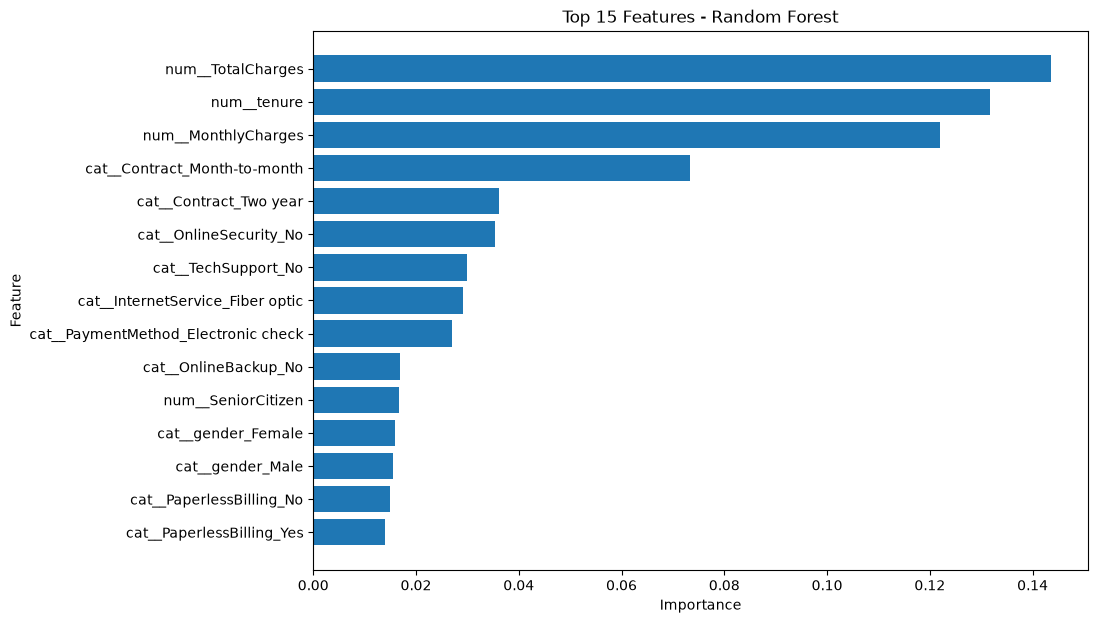

In [37]:
top_features = feature_importance.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features - Random Forest")
plt.show()

In [38]:
results_df.to_csv(
    "../data/output/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully.")

Model comparison saved successfully.


In [39]:
feature_importance.to_csv(
    "../data/output/random_forest_feature_importance.csv",
    index=False
)

print("Feature importance saved successfully.")

Feature importance saved successfully.


Gradient Boosting achieved the highest overall accuracy (79.86%) and precision (64.98%), while Logistic Regression achieved the highest churn recall (77.96%) and tied for the highest ROC-AUC (0.840). SVM achieved the highest F1-score (0.633). Therefore, model selection should consider the business objective rather than accuracy alone.

### validation


In [40]:
from sklearn.model_selection import StratifiedKFold, cross_validate

In [42]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [43]:
validation_models = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model,
    "Gradient Boosting": gradient_boosting_model,
    "SVM": svm_model
}

validation_results = []

for model_name, model in validation_models.items():

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    validation_results.append({
        "Model": model_name,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Precision": scores["test_precision"].mean(),
        "CV Recall": scores["test_recall"].mean(),
        "CV F1": scores["test_f1"].mean(),
        "CV ROC-AUC": scores["test_roc_auc"].mean()
    })

validation_df = pd.DataFrame(validation_results)

validation_df

,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC
0,Logistic Regression,0.747898,0.515266,0.802369,0.627432,0.845447
1,Random Forest,0.768693,0.556445,0.624666,0.588356,0.822065
2,Gradient Boosting,0.804157,0.665843,0.523418,0.585445,0.847391
3,SVM,0.748895,0.516881,0.782446,0.622402,0.826051


In [44]:
validation_details = []

for model_name, model in validation_models.items():

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    validation_details.append({
        "Model": model_name,
        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Accuracy Std": scores["test_accuracy"].std(),
        "F1 Mean": scores["test_f1"].mean(),
        "F1 Std": scores["test_f1"].std(),
        "ROC-AUC Mean": scores["test_roc_auc"].mean(),
        "ROC-AUC Std": scores["test_roc_auc"].std()
    })

validation_details_df = pd.DataFrame(validation_details)

validation_details_df

,Model,Accuracy Mean,Accuracy Std,F1 Mean,F1 Std,ROC-AUC Mean,ROC-AUC Std
0,Logistic Regression,0.747898,0.011664,0.627432,0.014671,0.845447,0.010209
1,Random Forest,0.768693,0.011130,0.588356,0.014553,0.822065,0.011924
2,Gradient Boosting,0.804157,0.009167,0.585445,0.021053,0.847391,0.010195
3,SVM,0.748895,0.009693,0.622402,0.013110,0.826051,0.014917


In [45]:
validation_df.to_csv(
    "../data/output/cross_validation_results.csv",
    index=False
)

validation_details_df.to_csv(
    "../data/output/cross_validation_details.csv",
    index=False
)

print("Cross-validation results saved successfully.")

Cross-validation results saved successfully.
